### Create synthetic dataset

In [1]:
import sys
import os

sys.path.append(os.getcwd())
# append the root directory to the sys.path

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

%load_ext autoreload
%autoreload 2

#### Necessary imports

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from src.utils.synthetic_dataset import GenerateData, MultimodalDataset
from src.utils.helpers import linear_probe, extract_latents_and_labels, plot_confusion_matrix


In [10]:
N_data = 10000
trans_type = "uniform"
latent_dims = {'Z1': 3, 'Zs': 3, 'Z2': 3}
dist = "normal"
t1 = 5
t2 = 5
sigmas = [0.1, 0.1, 0.1]
gamma1 = 1.5
gamma2 = 1.5
normalize = True

In [17]:
gen_data = GenerateData(N_data= N_data, trans_type= trans_type, latent_dims= latent_dims)
gen_data.create_dataset(dist= dist, t1= t1, t2= t2, gamma1= gamma1, gamma2= gamma2, normalize= normalize, sigmas= sigmas)
# dataset = MultimodalDataset(total_data= gen_data.dataset_dict['total_data'], labels_1= gen_data.dataset_dict['labels_1'], labels_2= gen_data.dataset_dict['labels_2'], labels_s= gen_data.dataset_dict['labels_s'])

Transformation matrices not found, creating with default parameters for each modality.
before: Z1 = [ 0.09973755 -0.17214808  0.03734839 -0.4358622   0.39480029  0.17830028]
 W1 = [[[-0.17799258  0.02835642 -0.72209602  0.          0.
    0.        ]
  [ 0.42408732  0.61536464  0.38836012  0.          0.
    0.        ]
  [ 0.10369791  0.63073288  0.40152393  0.          0.
    0.        ]
  [ 0.          0.          0.         -0.10938123 -0.70889915
   -0.08978092]
  [ 0.          0.          0.         -0.53103649 -0.38700823
   -0.4532546 ]
  [ 0.          0.          0.         -0.01011164 -0.72736252
   -0.99680962]]

 [[ 0.73420452  0.36054032 -0.13215397  0.          0.
    0.        ]
  [ 0.78024626 -0.38293731 -0.32325053  0.          0.
    0.        ]
  [ 0.43360379 -0.86748998  0.88701043  0.          0.
    0.        ]
  [ 0.          0.          0.          0.47555132 -0.92802496
    0.27015423]
  [ 0.          0.          0.          0.10721606  0.45989377
   -0.9009702

### Check Data creation

In [ ]:
import torch

# Normal
a = torch.normal(0.5, 1.0, size=(1,3))
b = torch.normal(2.0, 1.0, size=(1,3))
c = torch.cat((a, b), dim= -1)
print(f"a sample: {a}, b : {b}, c: {c}, normalized c: {c / torch.norm(c, dim=-1, keepdim=True)}")

a sample: tensor([[0.1724, 1.8671, 0.3504]]), b : tensor([[2.6743, 2.9428, 1.2260]]), c: tensor([[0.1724, 1.8671, 0.3504, 2.6743, 2.9428, 1.2260]]), normalized c: tensor([[0.0377, 0.4079, 0.0765, 0.5842, 0.6429, 0.2678]])


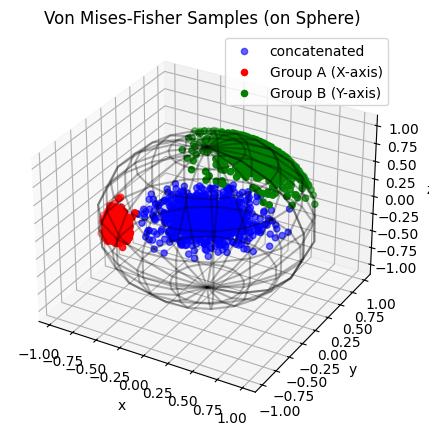

In [83]:
from scipy.stats import vonmises_fisher, multivariate_normal
import numpy as np
# 1. Define directions (Mean vectors on the sphere)
# Must be unit vectors!
loc_a = torch.randn(3) # Points along X
loc_a = loc_a / torch.norm(loc_a)
loc_b = torch.randn(3) # Points along Y
loc_b = loc_b / torch.norm(loc_b)


# 2. Define concentration (kappa)
# Higher = tighter cluster
k_a, k_b = 150.0, 20.0 

# 3. Sample using Scipy
# vonmises_fisher(mu, kappa).rvs(n) returns (n, 3) coordinates
n_samples = 1000
a_samples_np = vonmises_fisher(loc_a, k_a).rvs(n_samples)
b_samples_np = vonmises_fisher(loc_b, k_b).rvs(n_samples)

# Convert to tensor if needed for your pipeline
a_samples = torch.from_numpy(a_samples_np).float()
b_samples = torch.from_numpy(b_samples_np).float()
c = torch.cat((a_samples, b_samples), dim= -1).numpy()

# project c to three dimensions using PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
c = pca.fit_transform(c)

# 4. Plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Draw the unit sphere wireframe for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.3)
ax.scatter(c[:, 0], c[:, 1], c[:, 2], alpha=0.6, label='concatenated', color='b')
ax.scatter(a_samples[:, 0], a_samples[:, 1], a_samples[:, 2], color='r', label='Group A (X-axis)')
ax.scatter(b_samples[:, 0], b_samples[:, 1], b_samples[:, 2], color='g', label='Group B (Y-axis)')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Von Mises-Fisher Samples (on Sphere)")
plt.show()


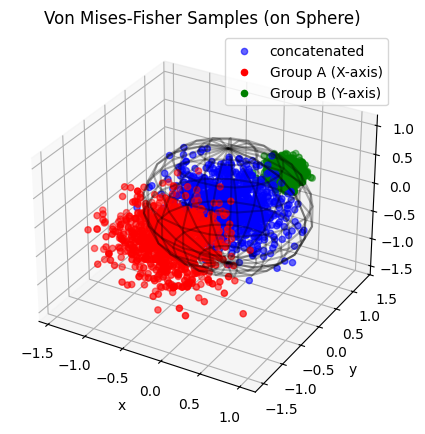

In [79]:
a_mean = torch.zeros(3) - 0.5
b_mean = torch.zeros(3) + 0.5
a_cov = torch.eye(3) * 0.1
b_cov = torch.eye(3) * 0.01

# vonmises_fisher(mu, kappa).rvs(n) returns (n, 3) coordinates
n_samples = 1000
a_samples_np = multivariate_normal(mean=a_mean.numpy(), cov=a_cov.numpy()).rvs(n_samples)
b_samples_np = multivariate_normal(mean=b_mean.numpy(), cov=b_cov.numpy()).rvs(n_samples)

# Convert to tensor if needed for your pipeline
a_samples = torch.from_numpy(a_samples_np).float()
b_samples = torch.from_numpy(b_samples_np).float()
c = torch.cat((a_samples, b_samples), dim= -1).numpy()

# project c to three dimensions using PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=3)
c = pca.fit_transform(c)

# 4. Plot
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")

# Draw the unit sphere wireframe for reference
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax.plot_wireframe(x, y, z, color="k", alpha=0.3)

ax.scatter(c[:, 0], c[:, 1], c[:, 2], alpha=0.6, label='concatenated', color='b')
ax.scatter(a_samples[:, 0], a_samples[:, 1], a_samples[:, 2], color='r', label='Group A (X-axis)')
ax.scatter(b_samples[:, 0], b_samples[:, 1], b_samples[:, 2], color='g', label='Group B (Y-axis)')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Von Mises-Fisher Samples (on Sphere)")
plt.show()

In [13]:
dataloader = DataLoader(dataset, batch_size= 1, shuffle= True)

for x1, x2, y1, y2, ys in dataloader:
    x1_aug = gen_data.augment_data(x1, aug_type="noise", scale= 1e-3)
    print(f"Original x1: {x1}")
    print(f"Augmented x1: {x1_aug}")
    break

Original x1: tensor([[[ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691],
         [ 0.3523, -0.0550,  0.1159, -0.1560,  0.1403,  0.2215, -0.1995,
           0.4225, -0.3493,  0.3290, -0.0713,  0.1731, -0.0102,  0.2414,
          -0.0656,  0.4691]]])
Augmented x1: tensor([[[ 0.3563, -0.0548,  0.1173, -0.1559,  0.1388,  0.2208, -0.1989,
           0.4254, -0.3